# Deep Learning Assignment 1

Name - Shrey Rastogi

Student ID - 25298964

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Using sigmoid as activation function and binary cross entropy as loss function from the lecture notes.

In [2]:
def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y, yhat):
    # cost function
    return - (y * np.log(yhat) + (1 - y) * np.log(1 - yhat))

## Task 1

This implements a logistic regression model trained with stochastic gradient descent. We don't need a hidden layer here, therefore only 1 output layer with 1 weight and 1 bias.

In [3]:
def train_logistic_regression(X, y, lr=0.01, max_iter=1000, threshold=0.5, N=100):
    # initialization
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0.0
    J_running = 0.0
    J_running_prev = 0.0
    iteration = 0
    stopping = False

    while not stopping: # while not converged

        # pick random examples from the training data
        random = np.random.randint(len(y))
        x_r = X[random]
        y_r = y[random]

        # Calculate y_hat from x, w, b
        # forward propagation stage
        z_i = np.dot(w, x_r) + b
        y_hat_i = _sigmoid(z_i)

        J_current = binary_cross_entropy(y_r, y_hat_i)

        # gradient descent stage
        error = y_hat_i - y_r
        delta_w = error * x_r
        delta_b = error

        w -= lr * delta_w
        b -= lr * delta_b

        iteration += 1
        J_running += J_current

        # Check stopping criteria
        if iteration >= max_iter:  # if number of iterations have been reached then we stop.
            stopping = True

        if (iteration % N) == 0:
            diff = abs(J_running - J_running_prev)
            if diff < threshold:
                stopping = True # loss while iterating is minimized by keeping it less than the threshold

            J_running_prev = J_running
            J_running = 0.0
    return w,b

def predict(X, w, b, threshold = 0.5):
    #print(w)
    #print(b)
    z = np.dot(X, w) + b
    prob = _sigmoid(z)
    #print("prob",prob.shape)
    y_pred = (prob >= threshold).astype(int)

    return y_pred

In [4]:
df = pd.read_csv("blobs600.csv")
df2 = pd.read_csv("circles500.csv")

y = df['Class'].values
y2 = df2['Class'].values

del df['Class']
X = df.values

del df2['Class']
X2 = df2.values

## Task 2

Dividing each dataset into appropriate sets (train, test, validation) and evaluate the performance of the model implemented in the above section on these datasets.

Visualizing the performance of the model through scatter plots to better interpret the results.

### Blobs Dataset

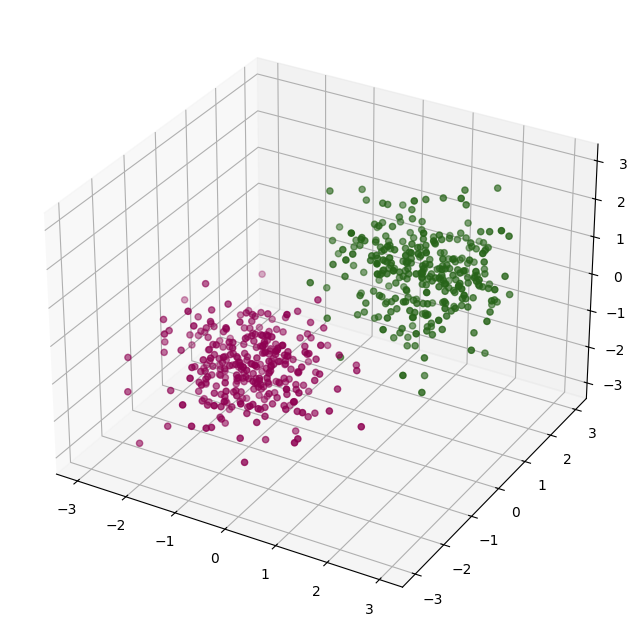

In [5]:
fig = plt.figure(figsize=(8, 8)) # set the size to 8x8
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap="PiYG")
plt.show()
plt.close(fig)

Splitting the data twice -
to make sure the training data is 70% and test 30%, and then splitting the test data again by half so we have 15% each of test and validation data

Blobs test accuracy:  0.989
Blobs validation accuracy:  1.000


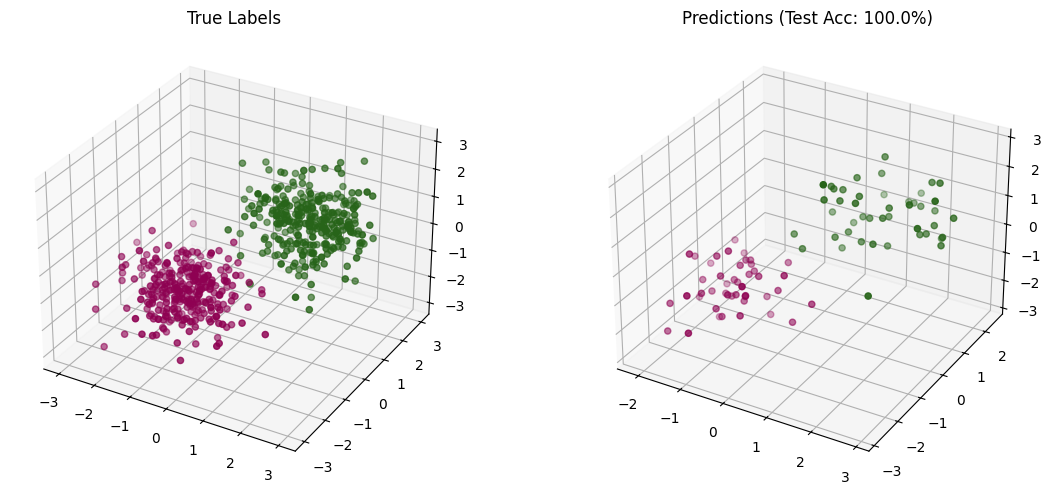

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
w, b = train_logistic_regression(X_train, y_train)

# no need for hyperparameter tuning for validation set, since the accuracy of 1 is reached on test data with default parameters itself.


y_test_pred = predict(X_test, w, b)
y_val_pred = predict(X_val, w, b)
test_acc = np.mean(y_test_pred == y_test)
val_acc = np.mean(y_val_pred == y_val)
print(f"Blobs test accuracy:  {test_acc:.3f}")
print(f"Blobs validation accuracy:  {val_acc:.3f}")

fig = plt.figure(figsize=(12, 5))
# True labels same as displayed above
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X[:, 0], X[:, 1], X[:,2], c=y, cmap="PiYG")
ax1.set_title("True Labels")

# Predictions
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(X_test[:, 0], X_test[:, 1], X_test[:,2], c=y_test_pred, cmap="PiYG")
ax2.set_title(f"Predictions (Test Acc: {val_acc:.1%})")

plt.tight_layout()
plt.show()

### Cirlces Dataset

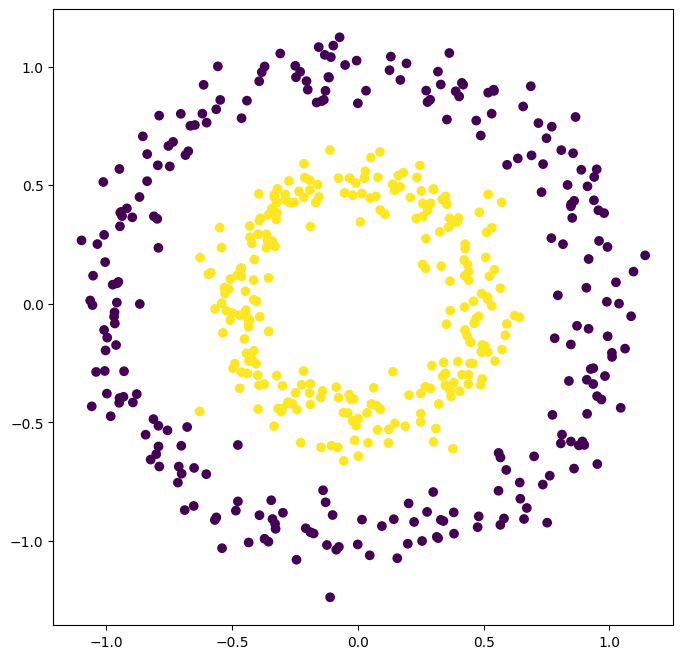

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(X2[:,0], X2[:,1], c=y2)
plt.show()
plt.close(fig)

Circles test accuracy:  0.573
Circles validation accuracy:  0.413


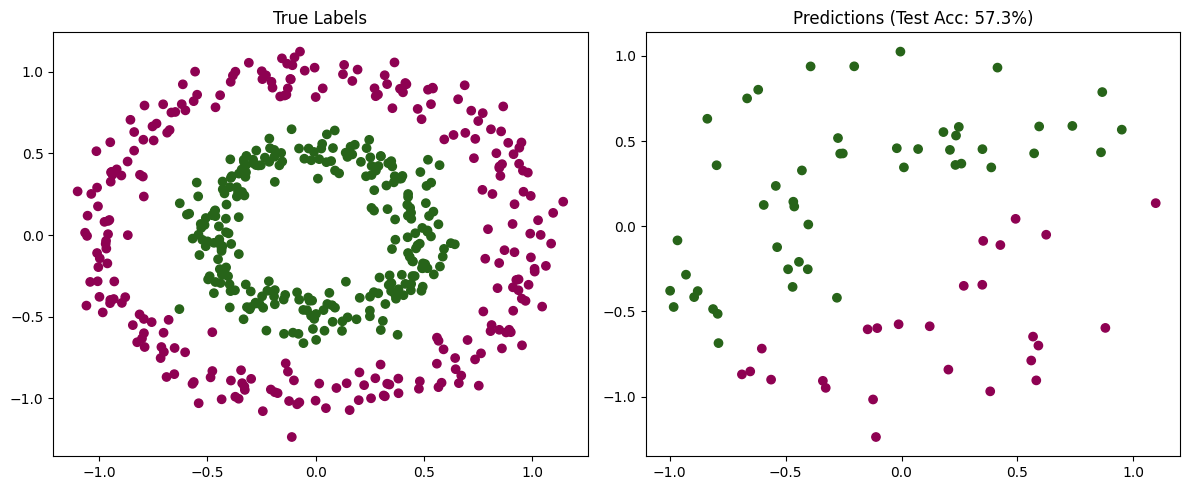

In [8]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)
X_test2, X_val2, y_test2, y_val2 = train_test_split(X_test2, y_test2, test_size=0.5, random_state=42)
w2, b2 = train_logistic_regression(X_train2, y_train2)

# hyperparameter tuning on validation set
w2_val, b2_val = train_logistic_regression(X_train2, y_train2, lr=0.08, max_iter=1000, threshold=0.8, N=10)

y_test_pred2 = predict(X_test2, w2, b2)
y_val_pred2 = predict(X_val2, w2_val, b2_val)
test_acc2 = np.mean(y_test_pred2 == y_test2)
val_acc2 = np.mean(y_val_pred2 == y_val2)

print(f"Circles test accuracy:  {test_acc2:.3f}")
print(f"Circles validation accuracy:  {val_acc2:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# True labels
ax1.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="PiYG")
ax1.set_title("True Labels")

# Predictions
ax2.scatter(X_test2[:, 0], X_test2[:, 1], c=y_test_pred2, cmap="PiYG")
ax2.set_title(f"Predictions (Test Acc: {test_acc2:.1%})")

plt.tight_layout()
plt.show()

## Task 3

Implementing a shallow neural network with 1 hidden later this time, extending on the regression model developed above.

The base is same, what different this time is supporting 2 weights and 2 bias, one for each layer (1 hidden and 1 output)

In [9]:
def train_shallow_nn(X, y, hidden=4, lr=0.1, max_iter=10000, threshold=1e-4, N=100):
    n_features = X.shape[1]
    n_samples = len(y)

    # Initialisation: small random values (0.01)
    np.random.seed(42)
    w1 = np.random.normal(0, 0.01, (n_features, hidden))
    b1 = np.zeros(hidden)
    w2 = np.random.normal(0, 0.01, (hidden, 1))
    b2 = np.zeros(1)

    J_running = 0.0
    J_running_prev = 0.0
    iterations = 0
    losses = []
    stopping = False

    while not stopping:
        # pick random values for X and y until we stop
        random = np.random.randint(n_samples)
        x_r = X[random:random+1]
        y_r = float(y[random])

        # forward propagation - Layer 1 - which is the hidden layer
        z1 = np.dot(x_r, w1) + b1.reshape(1, -1)
        a1 = np.tanh(z1)     # using tanh as the activation function

        # layer 2 - which is the output layer
        z2 = np.dot(a1, w2) + b2.reshape(1, -1)
        a2 = _sigmoid(z2)

        # now backpropagation
        J_current = binary_cross_entropy(y_r, a2[0,0])

        error2 = a2 - y_r  # error in output layer

        dw2 = lr * np.dot(error2.T, a1)
        db2 = lr * np.sum(error2)

        # error in hidden layer
        error1 = np.dot(error2, w2.T) * (1 - np.tanh(z1)**2) # derivative of tanh function used above
        dw1 = lr * np.dot(x_r.T, error1)
        db1 = lr * np.sum(error1)

        # updating the parameters based on the learning rate
        w2 -= dw2.T
        b2 -= db2
        w1 -= dw1
        b1 -= db1

        iterations += 1
        J_running += J_current

        if iterations >= max_iter:
            stopping = True

        if iterations % N == 0:
            avg = J_running / N
            losses.append(avg)
            diff = abs(J_running - J_running_prev)
            if diff < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0.0

    return (w1, b1, w2, b2, losses)


def predict_nn(X, w1, b1, w2, b2, threshold=0.0):
    z1 = np.dot(X, w1) + b1
    a1 = np.tanh(z1)

    z2 = np.dot(a1, w2) + b2
    prob = np.tanh(z2)
    #print("prob shape:", prob.shape)
    y_pred = (prob >= threshold).astype(int).flatten()

    return y_pred

### Blobs Dataset with Training Loss graph

Blobs test accuracy:  0.989
Blobs validation accuracy:  1.000


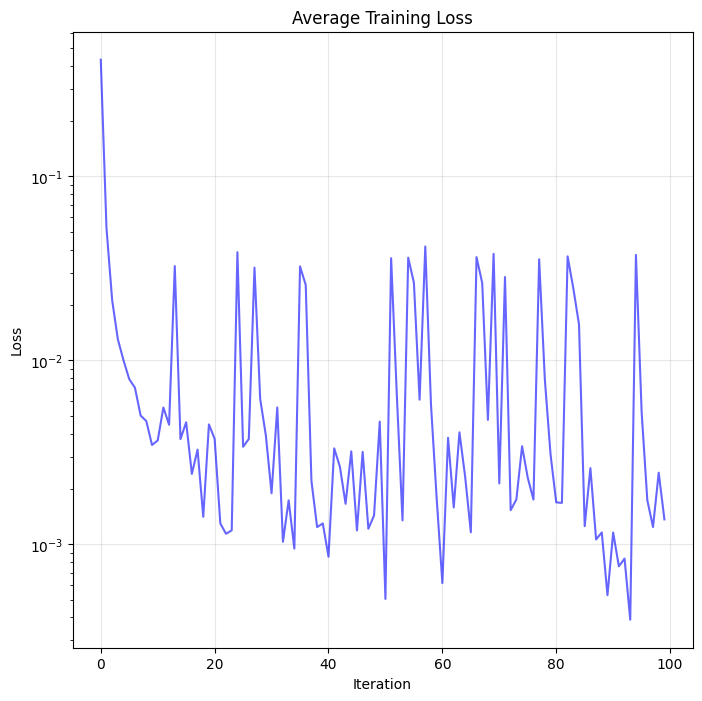

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test_new, X_val, y_test_new, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
w1, b1, w2, b2, losses = train_shallow_nn(X_train, y_train)


y_test_pred = predict_nn(X_test_new, w1, b1, w2, b2)
y_val_pred = predict_nn(X_val, w1, b1, w2, b2)
test_acc = np.mean(y_test_pred == y_test_new)
val_acc = np.mean(y_val_pred == y_val)
print(f"Blobs test accuracy:  {test_acc:.3f}")
print(f"Blobs validation accuracy:  {val_acc:.3f}")

fig, ax1 = plt.subplots(figsize=(8, 8))

ax1.plot(losses, alpha=0.6, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Average Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

### Circles dataset with Training Loss graph

Circles test accuracy:  0.533
Circles validation accuracy:  0.680


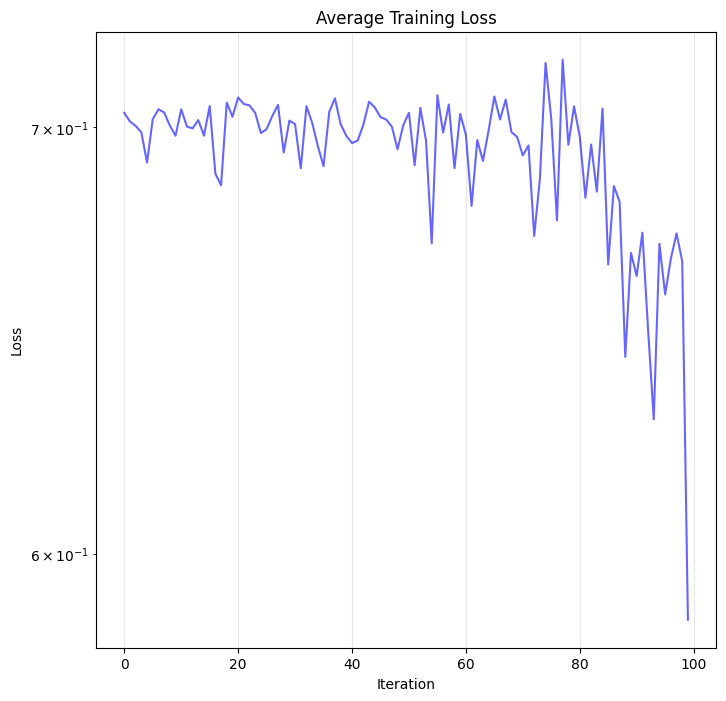

In [11]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=42)
X_test2_new, X_val2, y_test2_new, y_val2 = train_test_split(X_test2, y_test2, test_size=0.5, random_state=42)
w1, b1, w2, b2, losses  = train_shallow_nn(X_train2, y_train2)


y_test_pred2 = predict_nn(X_test2_new, w1, b1, w2, b2)
y_val_pred2 = predict_nn(X_val2, w1, b1, w2, b2)
test_acc2 = np.mean(y_test_pred2 == y_test2_new)
val_acc2 = np.mean(y_val_pred2 == y_val2)
print(f"Circles test accuracy:  {test_acc2:.3f}")
print(f"Circles validation accuracy:  {val_acc2:.3f}")

fig, ax1 = plt.subplots(figsize=(8, 8))

ax1.plot(losses, alpha=0.6, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Average Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

## Task 4

Using the same shallow neural network model from the previous section to distinguish between the letter 'N' and 'S' using Emnist Letters dataset.

In [12]:
data = np.load("emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]

In [13]:
# Extract just two classes from the dataset
# comparison of n and s
c1 = 14  # letter n
c2 = 19  # letter s

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c1).astype(int)

In [14]:
def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))

    for i in range(48):
        idx = n + i

        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Plot example of N

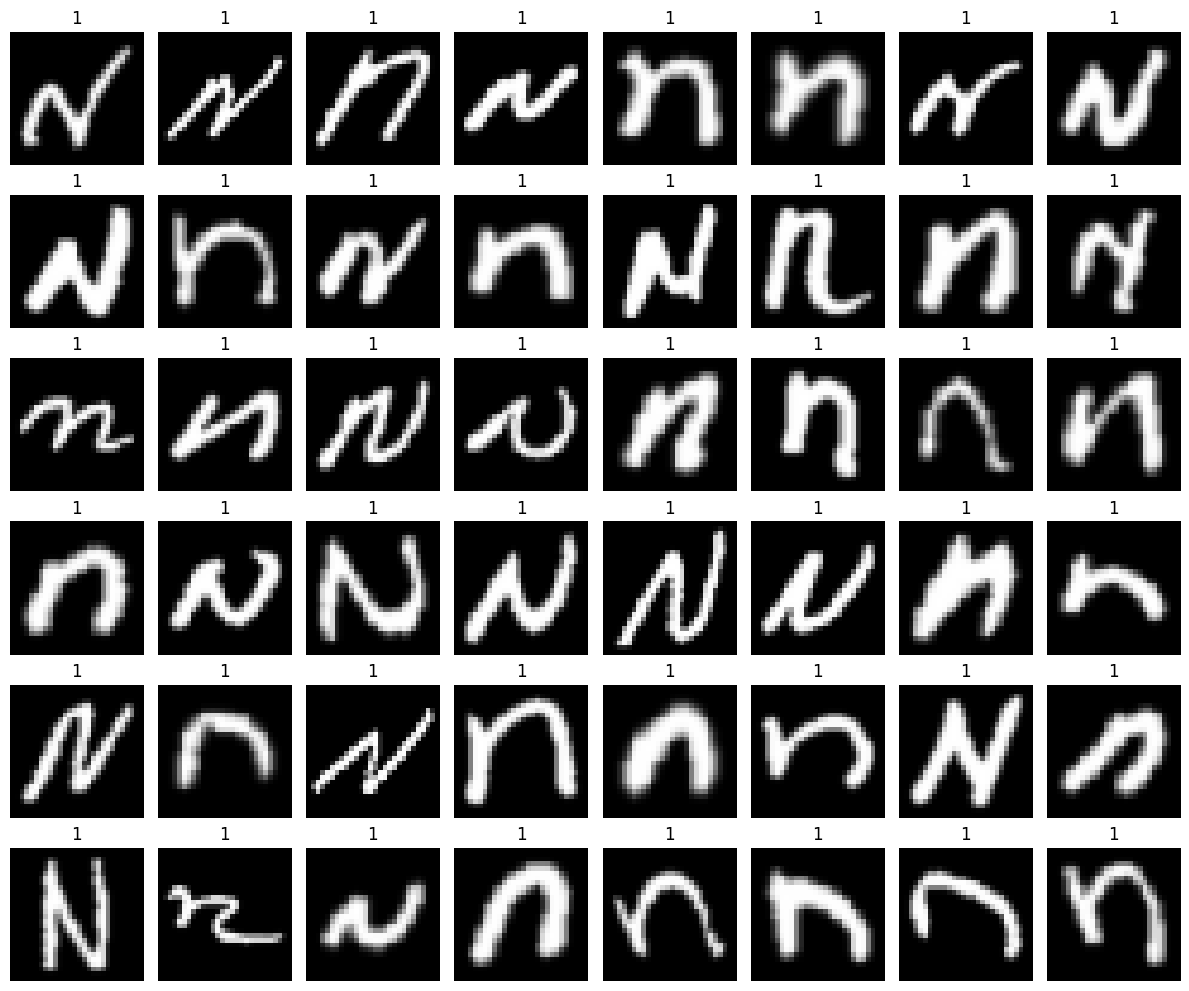

In [15]:
plot_grid(x_binary, y_binary, n=0)

### Plot example of S

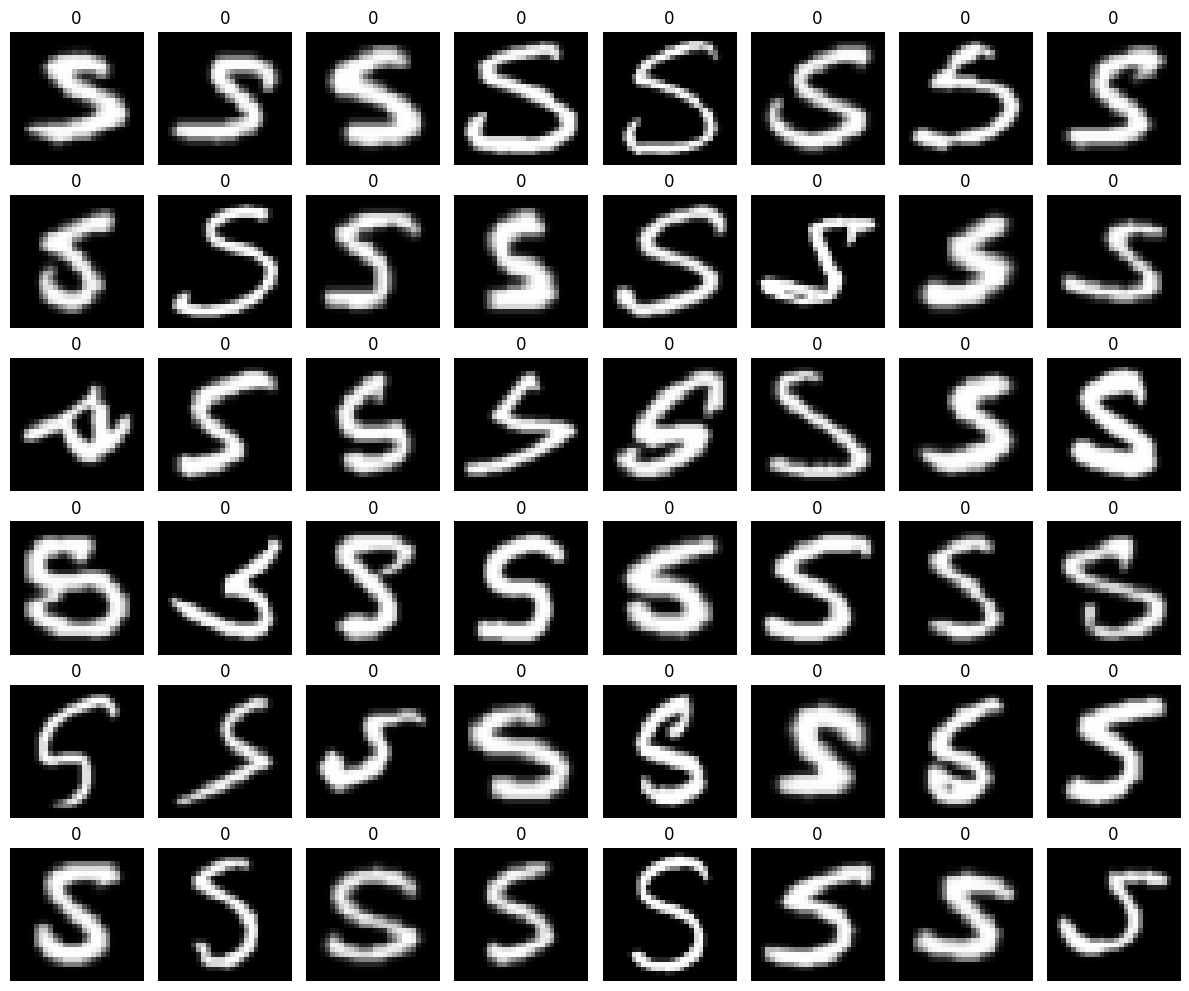

In [16]:
plot_grid(x_binary, y_binary, n=3300)

Test accuracy: 0.979
Validation accuracy: 0.989


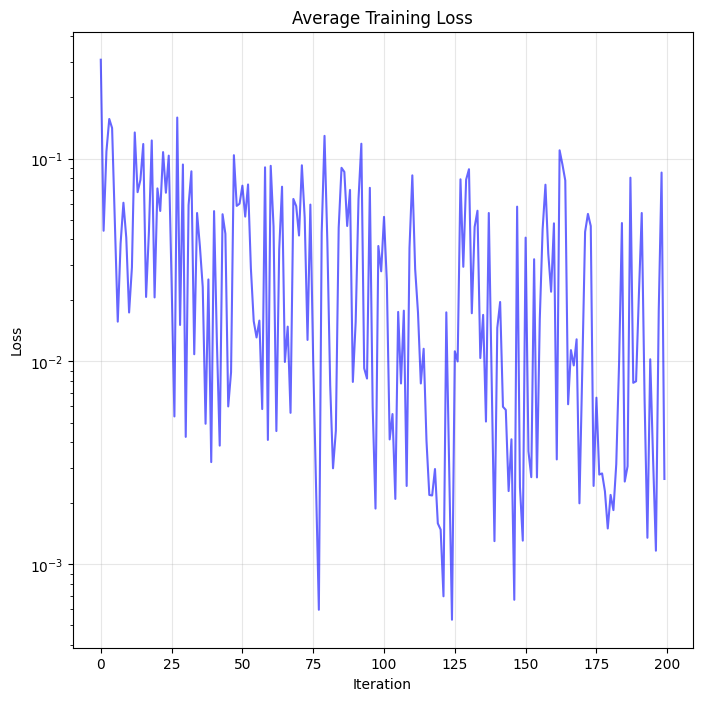

In [17]:
X_flat = x_binary.reshape(x_binary.shape[0], -1)

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_binary, test_size=0.3, random_state=42
)
X_test_new, X_val, y_test_new, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42
)

w1, b1, w2, b2, losses = train_shallow_nn(X_train, y_train)
y_pred_test = predict_nn(X_test_new, w1, b1, w2, b2)
print(f"Test accuracy: {np.mean(y_pred_test == y_test_new):.3f}")


w1, b1, w2, b2, losses = train_shallow_nn(
    X_train, y_train,
    hidden=32,
    lr=0.1,
    max_iter=20000
)
y_pred_val = predict_nn(X_val, w1, b1, w2, b2)
print(f"Validation accuracy: {np.mean(y_pred_val == y_val):.3f}")


fig, ax1 = plt.subplots(figsize=(8, 8))

ax1.plot(losses, alpha=0.6, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Average Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')


## Task 5

Building on the previous implementation of shallow neural networks which only had 1 hidden layer, we now build a deeper neural network which could support an arbitrary number of layers.

To achieve this, we convert weights and bias to lists since this depends on the layers now, and perform operation such as forward and backpropagation on all the layers instead of just 2 in the above section.

In [18]:
def train_deep_nn(X, y,layer_sizes, lr=0.1, max_iter=1000,threshold=1e-4, N=100, lambda_reg=0.0
):
    np.random.seed(42)
    n_layers = len(layer_sizes) - 1  # number of weight layers

    # Initialise parameters: lists of W,b since for different layer sizes
    # the number of weights and bias would be different
    w = []
    b = []
    for l in range(n_layers):
        input_layer = layer_sizes[l]
        output_layer = layer_sizes[l+1]
        w.append(np.random.normal(0, 0.01, (input_layer, output_layer)))
        b.append(np.zeros(output_layer))

    n_samples = len(y)
    J_running = 0.0
    J_running_prev = 0.0
    iterations = 0
    losses = []
    stopping = False

    while not stopping:
        # Keep picking random examples
        random = np.random.randint(n_samples)
        x_r = X[random:random+1]
        y_r = float(y[random])

        # forward pass
        z_layers = []
        a = x_r

        # apply activation functions based on layers
        for i in range(n_layers):
            z = np.dot(a, w[i]) + b[i]  # (1, n_out)

            # apply tanh function to the hidden layers
            if i < n_layers - 1:
                a = np.tanh(z)
            # apply sigmoid function to the output layer
            else:
                a = _sigmoid(z)
            z_layers.append(z)

        y_hat = a[0, 0]
        J_current = binary_cross_entropy(y_r, y_hat)

        # backpropagation
        prev_a_output = np.tanh(z_layers[-2])

        # output layer gradients
        error = a - y_r
        dw = [None] * n_layers
        db = [None] * n_layers
        dw[-1] = lr * np.dot(prev_a_output.T, error)
        db[-1] = lr * np.sum(error)

        # backpropagate through hidden layers and using derivation of activation function
        for i in range(n_layers-2, -1, -1):
            prev_a = np.tanh(z_layers[i-1]) if i > 0 else x_r
            error1 = np.dot(error, w[i+1].T) * (1 - np.tanh(z_layers[i])**2)
            dw[i] = lr * np.dot(prev_a.T, error1)
            db[i] = lr * np.sum(error1)
            error = error1

        # adding L2 regularization for overfitting
        for i in range(n_layers):
            dw[i] += lambda_reg * w[i]

        for i in range(n_layers):
            w[i] -= dw[i]
            b[i] -= db[i]

        # checking convergence
        iterations += 1
        J_running += J_current

        if iterations >= max_iter:
            stopping = True

        if iterations % N == 0:
            avg = J_running / N
            losses.append(avg)
            diff = abs(J_running - J_running_prev)
            if diff < threshold:
                stopping = True
            J_running_prev = J_running
            J_running = 0.0

    return w, b, losses

def predict_deep_nn(X, w, b, threshold=0.5):
    a = X
    n_layers = len(w)
    for l in range(n_layers):
        z = np.dot(a, w[l]) + b[l]
        if l < n_layers - 1:
            a = np.tanh(z)
        else:
            a = _sigmoid(z)
    probs = a
    y_pred = (probs >= threshold).astype(int).flatten()
    return y_pred


Test accuracy: 0.985
Validation accuracy: 0.983


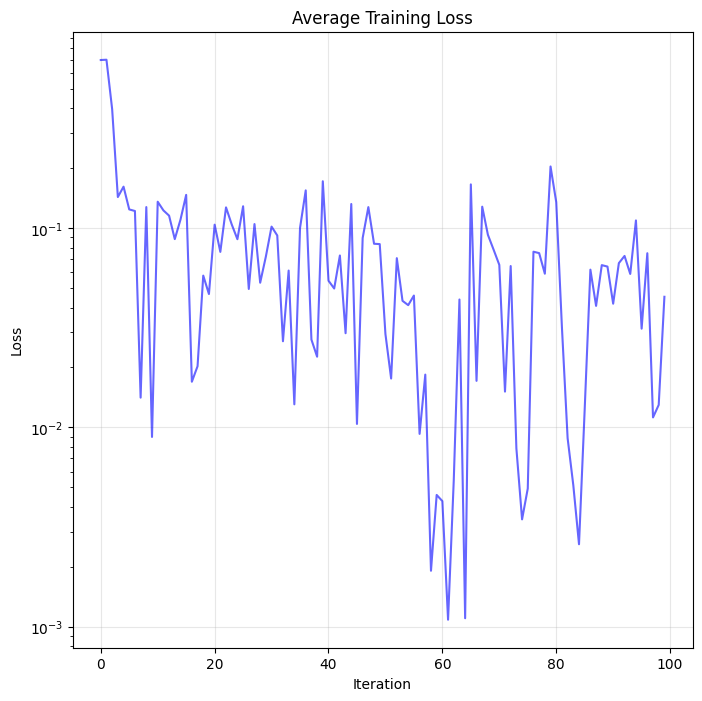

In [19]:

X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y_binary, test_size=0.3, random_state=42
)
X_test_new, X_val, y_test_new, y_val = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42
)

w1, b1, losses = train_deep_nn(
    X_train, y_train,
    layer_sizes=[X_train.shape[1], 16, 8, 1],
)

y_test_pred = predict_deep_nn(X_test_new, w1, b1)
print(f"Test accuracy: {np.mean(y_test_pred == y_test_new):.3f}")

w2, b2, losses2 = train_deep_nn(
    X_train, y_train,
    layer_sizes=[X_train.shape[1], 16, 8, 1],
    lr=0.1,
    max_iter=10000,
    lambda_reg=0.0
)
y_val_pred = predict_deep_nn(X_val, w2, b2)
print(f"Validation accuracy: {np.mean(y_val_pred == y_val):.3f}")

fig, ax1 = plt.subplots(figsize=(8, 8))

ax1.plot(losses2, alpha=0.6, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Average Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')